# House Prices - Advanced Regression Techniques: Baseline Prototype

**SYS-304 — Milestone 1: Problem Scoping & The Prototype**

**Domain:** Tabular Regression
**Dataset:** [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) (Kaggle / Ames Housing Dataset)
**Goal:** Predict `SalePrice` for residential homes in Ames, Iowa from 79 explanatory features. This notebook builds a *naive baseline* — a working proof-of-concept pipeline (EDA → preprocessing → training → evaluation → saved weights), not a tuned, state-of-the-art model.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import joblib

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


Matplotlib is building the font cache; this may take a moment.


## 1. Load Data

In [5]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

print("train shape:", train_df.shape)
print("test shape :", test_df.shape)
train_df.head()


train shape: (1460, 81)
test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Exploratory Data Analysis (EDA)

We look at: overall structure, missing values, the target distribution, and which features
correlate most with `SalePrice`.

In [6]:
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [7]:
# Missing values (train set)
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
missing_summary = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
missing_summary = missing_summary[missing_summary["n_missing"] > 0].sort_values("pct_missing", ascending=False)
print(f"{len(missing_summary)} columns have missing values")
missing_summary.head(20)


19 columns have missing values


,n_missing,pct_missing
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


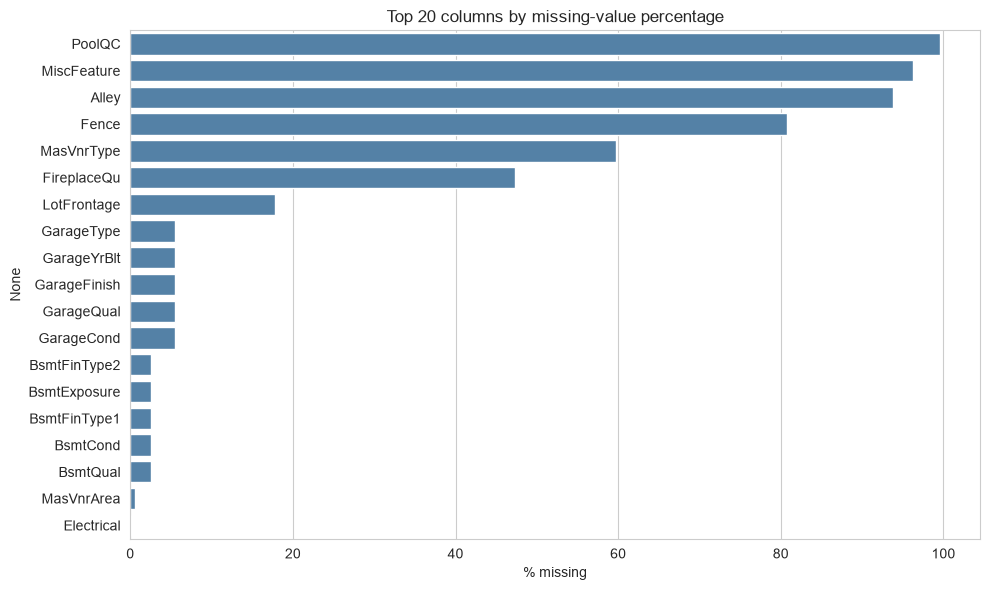

In [8]:
top_missing = missing_summary.head(20)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_missing["pct_missing"], y=top_missing.index, color="steelblue")
plt.xlabel("% missing")
plt.title("Top 20 columns by missing-value percentage")
plt.tight_layout()
plt.show()


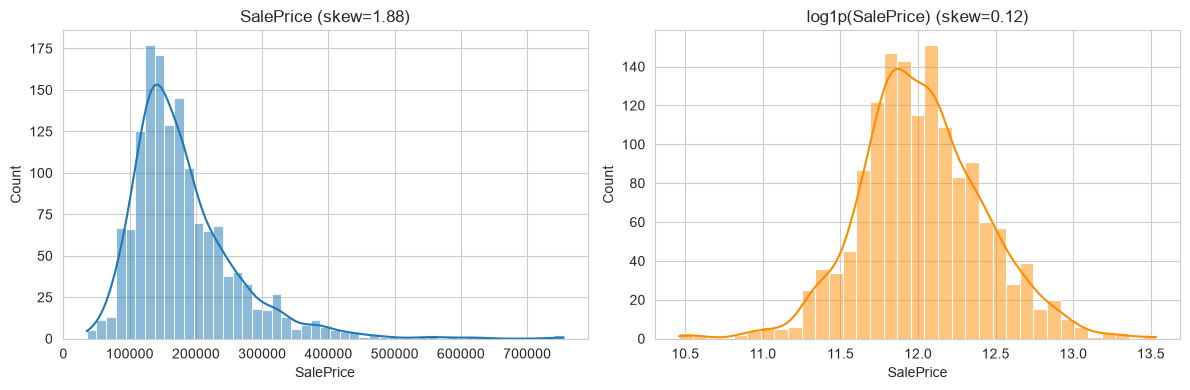

In [9]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title(f"SalePrice (skew={train_df['SalePrice'].skew():.2f})")

log_price = np.log1p(train_df["SalePrice"])
sns.histplot(log_price, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title(f"log1p(SalePrice) (skew={log_price.skew():.2f})")
plt.tight_layout()
plt.show()


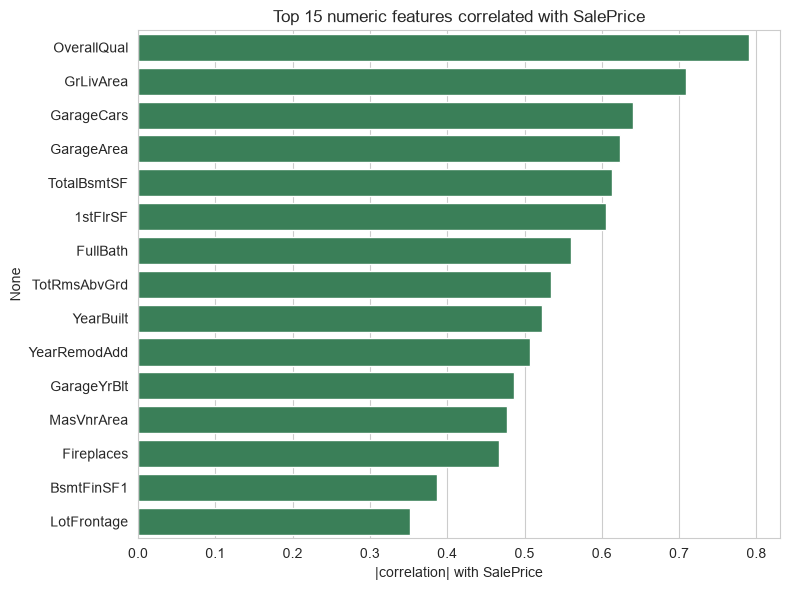

In [10]:
# SalePrice is right-skewed, so we'll train on log1p(SalePrice) and
# invert the transform (expm1) at prediction time — this is also the
# standard approach for this competition's evaluation metric (RMSLE).

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.drop(["Id", "SalePrice"])
corr = train_df[list(numeric_cols) + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice")
top_corr = corr.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_corr.values, y=top_corr.index, color="seagreen")
plt.xlabel("|correlation| with SalePrice")
plt.title("Top 15 numeric features correlated with SalePrice")
plt.tight_layout()
plt.show()


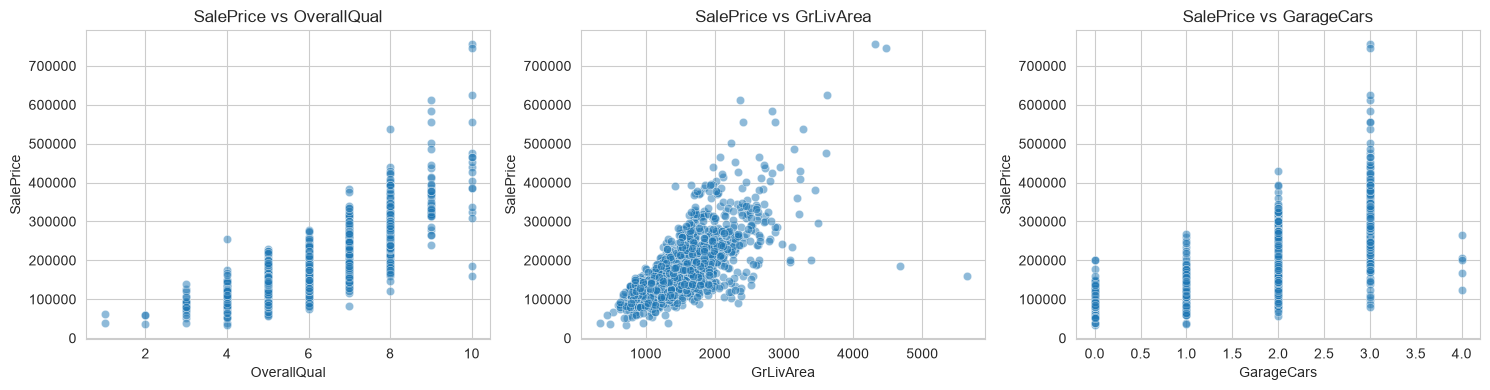

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["OverallQual", "GrLivArea", "GarageCars"]):
    sns.scatterplot(x=train_df[col], y=train_df["SalePrice"], ax=ax, alpha=0.5)
    ax.set_title(f"SalePrice vs {col}")
plt.tight_layout()
plt.show()


## 3. Preprocessing

For a *baseline*, we keep preprocessing simple and let a `ColumnTransformer` handle it
inside a single `sklearn` `Pipeline`, so the exact same steps are applied consistently to
train, validation, and any future/test data:

- **Numeric columns:** median imputation + standard scaling
- **Categorical columns:** most-frequent imputation + one-hot encoding (unknown categories at
  inference time are ignored rather than crashing the pipeline)
- **Target:** `log1p(SalePrice)`, inverted with `expm1` after prediction


In [12]:
y = np.log1p(train_df["SalePrice"])
X = train_df.drop(columns=["Id", "SalePrice"])

# Split columns into 2 groups, numeric and text
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print(f"{len(num_cols)} numeric columns, {len(cat_cols)} categorical columns")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols),
])


36 numeric columns, 43 categorical columns


/var/folders/00/ds43vb9x4_g70b_q0hgd6bn00000gn/T/ipykernel_82797/1547212973.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


## 4. Train / Validation Split

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("X_train:", X_train.shape, " X_val:", X_val.shape)


X_train: (1168, 79)  X_val: (292, 79)


## 5. Baseline Model Training

We use `XGBRegressor` with light, untuned defaults — this is the naive baseline the
milestone asks for, not a hyperparameter-tuned model.

In [14]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

model.fit(X_train, y_train)
print("Training complete.")


Training complete.


## 6. Evaluation

In [15]:
val_pred_log = model.predict(X_val)

rmse_log = np.sqrt(mean_squared_error(y_val, val_pred_log))          # competition metric (RMSLE)
val_pred = np.expm1(val_pred_log)
y_val_actual = np.expm1(y_val)
rmse_dollars = np.sqrt(mean_squared_error(y_val_actual, val_pred))
mae_dollars = mean_absolute_error(y_val_actual, val_pred)
r2 = r2_score(y_val_actual, val_pred)

print(f"Validation RMSE (log scale, ~Kaggle RMSLE): {rmse_log:.4f}")
print(f"Validation RMSE (dollars):                  ${rmse_dollars:,.0f}")
print(f"Validation MAE  (dollars):                  ${mae_dollars:,.0f}")
print(f"Validation R^2:                              {r2:.4f}")


Validation RMSE (log scale, ~Kaggle RMSLE): 0.1327
Validation RMSE (dollars):                  $26,211
Validation MAE  (dollars):                  $15,676
Validation R^2:                              0.9104


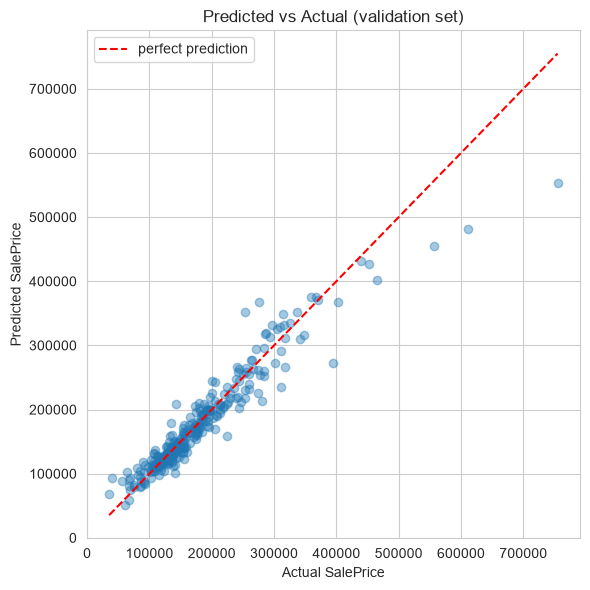

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val_actual, val_pred, alpha=0.4)
lims = [min(y_val_actual.min(), val_pred.min()), max(y_val_actual.max(), val_pred.max())]
plt.plot(lims, lims, "r--", label="perfect prediction")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Predicted vs Actual (validation set)")
plt.legend()
plt.tight_layout()
plt.show()


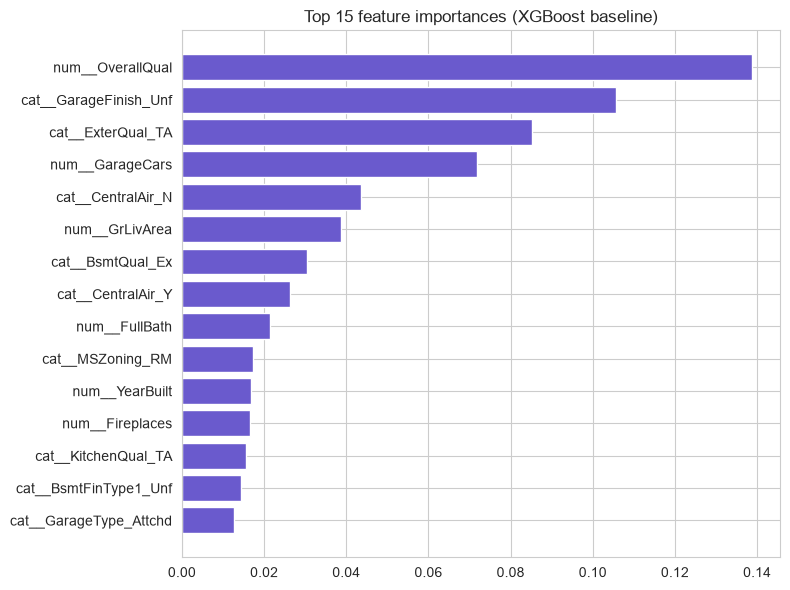

In [17]:
feature_importances = model.named_steps["regressor"].feature_importances_
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
top_idx = np.argsort(feature_importances)[-15:]

plt.figure(figsize=(8, 6))
plt.barh(feature_names[top_idx], feature_importances[top_idx], color="slateblue")
plt.title("Top 15 feature importances (XGBoost baseline)")
plt.tight_layout()
plt.show()


## 7. Save Model Weights

The **entire pipeline** (preprocessing + trained model) is saved with `joblib`, so it can be
reloaded and used for prediction on raw, unprocessed input without repeating any manual steps.

In [18]:
import os
os.makedirs("../models", exist_ok=True)
model_path = "../models/xgb_baseline_pipeline.pkl"
joblib.dump(model, model_path)
print(f"Saved baseline model to {model_path}")


Saved baseline model to ../models/xgb_baseline_pipeline.pkl


## 8. Reload & Predict (Inference Demo)

This cell demonstrates loading the saved weights from disk and running a successful
prediction — the step you can show in the screen-recording instead of re-running training.

In [19]:
loaded_model = joblib.load(model_path)

sample = X_val.head(5)
sample_pred_log = loaded_model.predict(sample)
sample_pred = np.expm1(sample_pred_log)

results = pd.DataFrame({
    "Actual_SalePrice": np.expm1(y_val.head(5)).values,
    "Predicted_SalePrice": sample_pred.round(2),
})
results["Abs_Error"] = (results["Actual_SalePrice"] - results["Predicted_SalePrice"]).abs().round(2)
results


,Actual_SalePrice,Predicted_SalePrice,Abs_Error
0,154500.0,146251.968750,8248.03
1,325000.0,334573.343750,9573.34
2,115000.0,112218.273438,2781.73
3,159000.0,157541.593750,1458.41
4,315500.0,332267.718750,16767.72


## 9. (Optional) Kaggle Submission File

Not required by the milestone, but a nice sanity check — this generates a `submission.csv`
in the same format Kaggle expects, using the saved model on the untouched `test.csv`.

In [ ]:
test_pred_log = loaded_model.predict(test_df.drop(columns=["Id"]))
test_pred = np.expm1(test_pred_log)

submission = pd.DataFrame({"Id": test_df["Id"], "SalePrice": test_pred})
submission.to_csv("../data/submission.csv", index=False)
submission.head()


## Summary

- Loaded the Ames Housing / House Prices train & test sets (1460 / 1459 rows, 79 features).
- Explored missingness, target skew, and the numeric features most correlated with `SalePrice`.
- Built a single `sklearn` `Pipeline` (median/most-frequent imputation + scaling/one-hot encoding
  + `XGBRegressor`) trained on `log1p(SalePrice)`.
- Baseline validation performance is printed in **Section 6** above (RMSE on the log scale is
  directly comparable to the Kaggle leaderboard's RMSLE metric).
- Saved the full pipeline to `models/xgb_baseline_pipeline.pkl` and confirmed it reloads and
  predicts correctly.

This is intentionally a *naive* baseline — no hyperparameter tuning, no advanced feature
engineering (e.g. combining basement/porch square footage, ordinal-encoding quality fields,
outlier removal). Those are natural next steps once this milestone's architecture is in place.
